# Final Model Evaluation
## Performance Evaluation, Metrics & Comparison

This notebook evaluates all three classifiers on the unified test set.

Feature space: Fine-tuned ResNet-50 + Clinical Metadata (2067-dim)
Label mapping: akiec=0, bcc=1, bkl=2, df=3, mel=4, nv=5, vasc=6

Final Results:
| Model    | Accuracy | F1-Macro | ROC-AUC |
|----------|----------|----------|---------|
| SVM      | 0.8527   | 0.7740   | 0.9671  |
| kNN+LDA  | 0.8597   | 0.7738   | 0.9056  |
| MLP      | 0.8637   | 0.7786   | 0.9626  |

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
os.makedirs('../outputs', exist_ok=True)
print("Libraries loaded.")
print("CLASS_NAMES:", CLASS_NAMES)

Libraries loaded.
CLASS_NAMES: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Load Test Data

In [5]:
X_test = np.load('../data/processed/X_test_fused_optimized.npy')
y_test = np.load('../data/processed/y_test_optimized.npy')

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

from collections import Counter
print("\nTest class distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {Counter(y_test)[i]}")

X_test shape: (2003, 2067)
y_test shape: (2003,)

Test class distribution:
  akiec: 65
  bcc: 103
  bkl: 220
  df: 23
  mel: 223
  nv: 1341
  vasc: 28


## Load Trained Models

In [6]:
import torch
import torch.nn as nn

class SkinLesionMLP(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(SkinLesionMLP, self).__init__()
        self.fc1 = nn.Linear(2067, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_rate)
        self.fc3 = nn.Linear(128, 7)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

print("SkinLesionMLP tanımlandı.")

SkinLesionMLP tanımlandı.


In [7]:
# SVM
with open('../saved_models/svm_final.pkl', 'rb') as f:
    svm_model = pickle.load(f)
with open('../saved_models/scaler_svm_final.pkl', 'rb') as f:
    scaler_svm = pickle.load(f)

# kNN
with open('../saved_models/knn_model_fused.pkl', 'rb') as f:
    knn_model = pickle.load(f)
with open('../saved_models/lda_transformer_fused.pkl', 'rb') as f:
    lda = pickle.load(f)
with open('../saved_models/scaler_fused.pkl', 'rb') as f:
    scaler_knn = pickle.load(f)

# MLP PyTorch
with open('../saved_models/mlp_pytorch_final.pkl', 'rb') as f:
    mlp_model = pickle.load(f)

print("Tüm modeller yüklendi.")
print("MLP tipi:", type(mlp_model))

Tüm modeller yüklendi.
MLP tipi: <class '__main__.SkinLesionMLP'>


## Prepare Transformed Test Data for kNN
kNN requires StandardScaler + LDA transformation before prediction.
SVM and MLP use raw fused features directly.

In [8]:
# SVM için scaler
X_test_svm = scaler_svm.transform(X_test)

# kNN için scaler + LDA
X_test_scaled = scaler_knn.transform(X_test)
X_test_lda    = lda.transform(X_test_scaled)

print("SVM input shape:", X_test_svm.shape)
print("kNN input shape:", X_test_lda.shape)
print("MLP input shape:", X_test.shape)

SVM input shape: (2003, 2067)
kNN input shape: (2003, 6)
MLP input shape: (2003, 2067)


## Evaluation Function
Reusable function for all models.
Note: kNN uses X_test_lda, SVM and MLP use X_test directly.

In [9]:
def evaluate_model(model, X, y_test, model_name, is_pytorch=False):
    if is_pytorch:
        import torch
        model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            outputs = model(X_tensor)
            probs = torch.softmax(outputs, dim=1).numpy()
            preds = torch.argmax(outputs, dim=1).numpy()
        y_pred  = preds
        y_proba = probs
    else:
        y_pred  = model.predict(X)
        try:
            y_proba = model.predict_proba(X)
        except AttributeError:
            from scipy.special import softmax
            y_scores = model.decision_function(X)
            y_proba = softmax(y_scores, axis=1)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Classification Report
    print(f"\n{'='*55}")
    print(f"  {model_name} — Classification Report")
    print('='*55)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Macro : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                cmap='Blues', ax=ax,
                annot_kws={'size': 11})
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=14, pad=15)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../outputs/{model_name}_confusion_matrix.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {model_name}_confusion_matrix.png")

    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1-Macro': f1,
        'ROC-AUC': auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

print("Evaluation function ready.")

Evaluation function ready.


## SVM Evaluation


  SVM — Classification Report
              precision    recall  f1-score   support

       akiec       0.59      0.72      0.65        65
         bcc       0.75      0.74      0.75       103
         bkl       0.73      0.70      0.71       220
          df       0.89      0.74      0.81        23
         mel       0.59      0.70      0.64       223
          nv       0.95      0.92      0.93      1341
        vasc       1.00      0.86      0.92        28

    accuracy                           0.85      2003
   macro avg       0.79      0.77      0.77      2003
weighted avg       0.86      0.85      0.86      2003

Accuracy : 0.8527
F1-Macro : 0.7740
ROC-AUC  : 0.9671


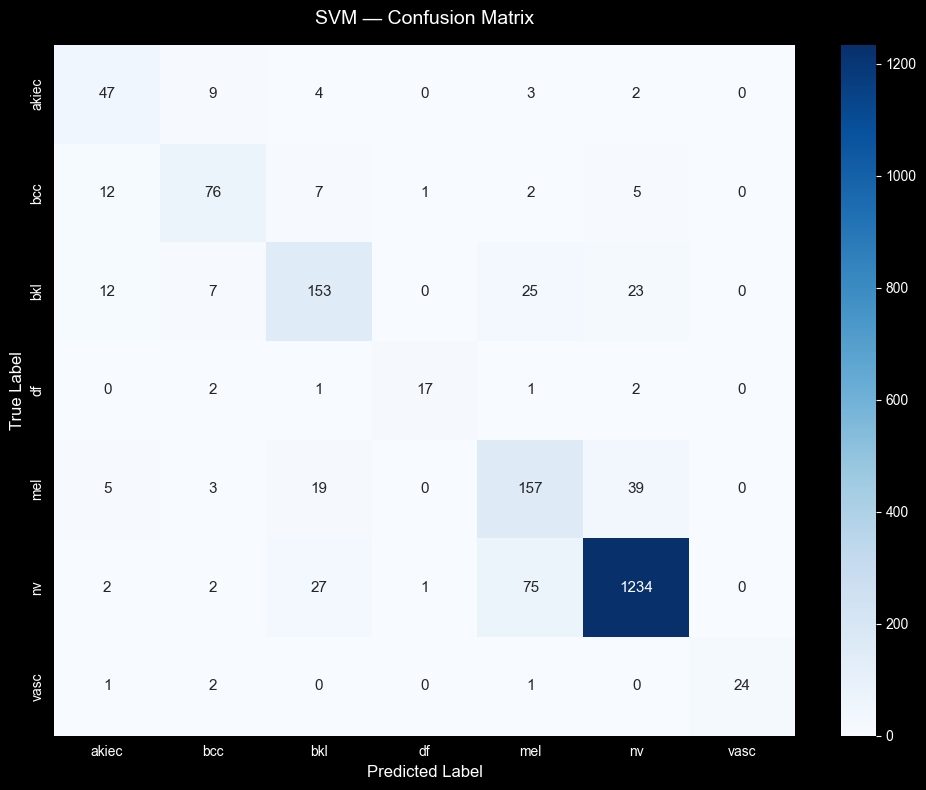

Saved: SVM_confusion_matrix.png


In [10]:
svm_results = evaluate_model(svm_model, X_test_svm, y_test, 'SVM')

## kNN + LDA Evaluation


  kNN_LDA — Classification Report
              precision    recall  f1-score   support

       akiec       0.64      0.66      0.65        65
         bcc       0.77      0.73      0.75       103
         bkl       0.76      0.67      0.71       220
          df       0.89      0.74      0.81        23
         mel       0.67      0.65      0.66       223
          nv       0.92      0.95      0.93      1341
        vasc       1.00      0.82      0.90        28

    accuracy                           0.86      2003
   macro avg       0.81      0.75      0.77      2003
weighted avg       0.86      0.86      0.86      2003

Accuracy : 0.8597
F1-Macro : 0.7738
ROC-AUC  : 0.9056


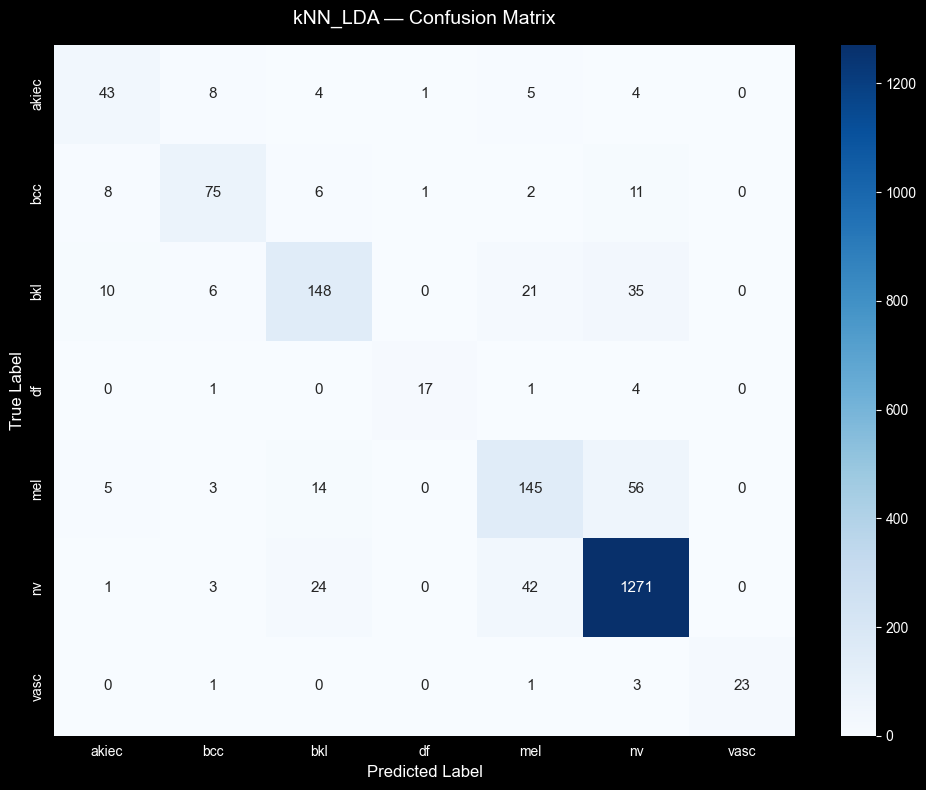

Saved: kNN_LDA_confusion_matrix.png


In [11]:
knn_results = evaluate_model(knn_model, X_test_lda, y_test, 'kNN_LDA')

## MLP Evaluation


  MLP — Classification Report
              precision    recall  f1-score   support

       akiec       0.72      0.60      0.66        65
         bcc       0.78      0.75      0.76       103
         bkl       0.72      0.74      0.73       220
          df       0.86      0.78      0.82        23
         mel       0.65      0.59      0.62       223
          nv       0.93      0.95      0.94      1341
        vasc       0.93      0.93      0.93        28

    accuracy                           0.86      2003
   macro avg       0.80      0.76      0.78      2003
weighted avg       0.86      0.86      0.86      2003

Accuracy : 0.8637
F1-Macro : 0.7786
ROC-AUC  : 0.9626


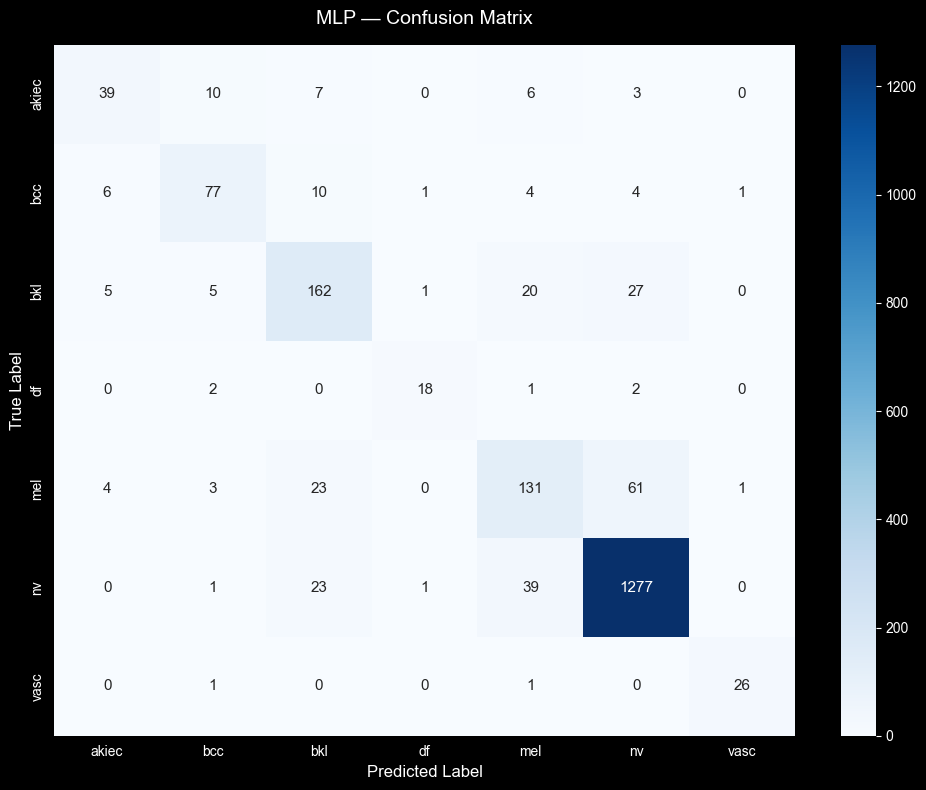

Saved: MLP_confusion_matrix.png


In [12]:
mlp_results = evaluate_model(mlp_model, X_test, y_test, 'MLP', is_pytorch=True)

## Final Comparison Table


       FINAL MODEL COMPARISON
         Accuracy  F1-Macro  ROC-AUC
Model                               
SVM        0.8527    0.7740   0.9671
kNN_LDA    0.8597    0.7738   0.9056
MLP        0.8637    0.7786   0.9626


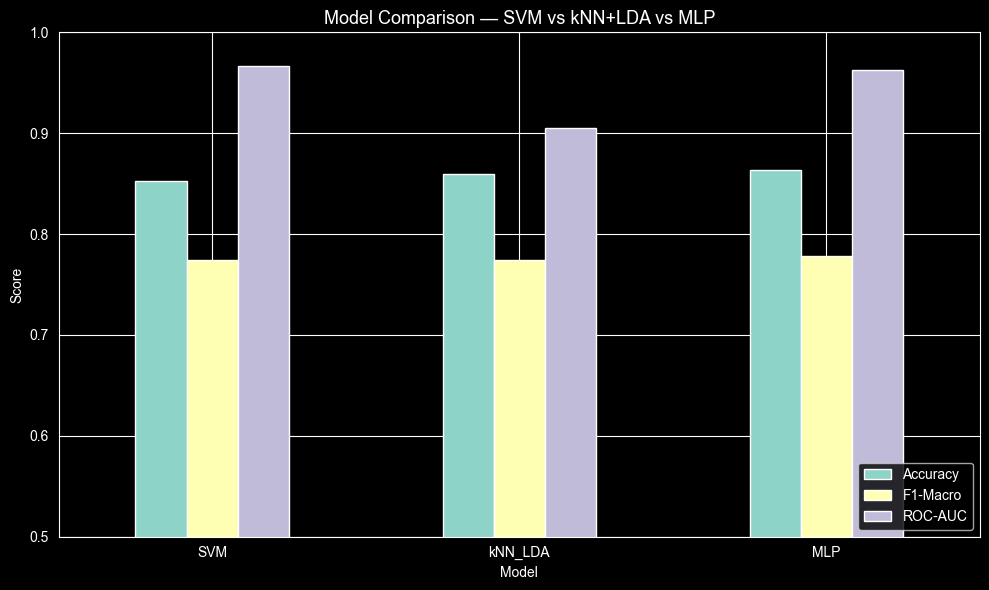

Saved: model_comparison.png


In [13]:
comparison = pd.DataFrame([
    {k: v for k, v in svm_results.items() if k not in ['y_pred', 'y_proba']},
    {k: v for k, v in knn_results.items() if k not in ['y_pred', 'y_proba']},
    {k: v for k, v in mlp_results.items() if k not in ['y_pred', 'y_proba']},
])
comparison = comparison.set_index('Model').round(4)

print("\n" + "="*50)
print("       FINAL MODEL COMPARISON")
print("="*50)
print(comparison.to_string())

# Bar chart
comparison.plot(kind='bar', figsize=(10, 6), ylim=(0.5, 1.0))
plt.title('Model Comparison — SVM vs kNN+LDA vs MLP', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: model_comparison.png")

## ROC Curves

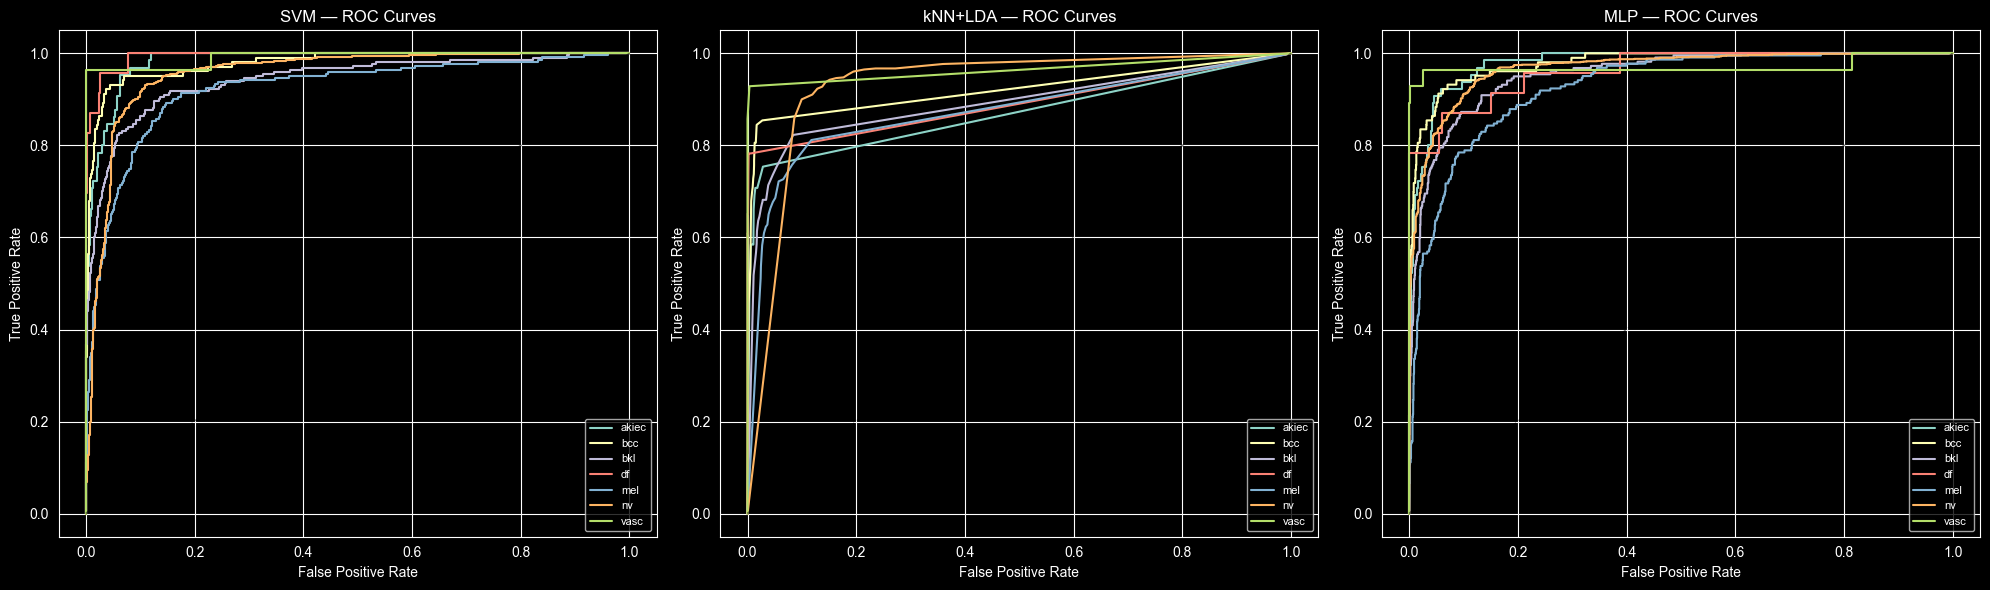

Saved: roc_curves.png


In [14]:
y_test_bin = label_binarize(y_test, classes=list(range(7)))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_roc = [
    (svm_results, 'SVM', axes[0]),
    (knn_results, 'kNN+LDA', axes[1]),
    (mlp_results, 'MLP', axes[2])
]

for result, name, ax in models_roc:
    y_proba = result['y_proba']
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label=f'{class_name}')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5)
    ax.set_title(f'{name} — ROC Curves', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: roc_curves.png")